### 📊 AED para explorar o IPV (Ponto de Virada)

**Base:** `df_base_2.parquet` — atualização gerada no Notebook `03_AED_IEG.ipynb`.

**❓Pergunta chave:**
- Quais comportamentos — acadêmicos, emocionais ou de engajamento — mais influenciam o IPV ao longo do tempo?

**Entendimentos**
- O IPV é numérico (0-10), avaliado pelos mestres
- "Comportamentos acadêmicos" → IDA, notas por disciplina
- "Comportamentos emocionais" → IPS, IAA
- "Comportamentos de engajamento" → IEG
- Talvez também possa incluir IPP e IAN para completar o quadro
- "Ao longo do tempo" = análise temporal: como o delta dos indicadores se relaciona com o IPV futuro

**Sub-perguntas:**
- Qual a distribuição do IPV por ano?
- Quais indicadores têm maior correlação com o IPV?
- Existe um perfil de aluno que atinge IPV alto?
- Como o IPV evolui ao longo do tempo para os mesmos alunos?

### ⚙️ Import e Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

df = pd.read_parquet('../data/processed/df_base_2.parquet')

print(f'df_base: {df.shape[0]} linhas | {df.shape[1]} colunas')

df_base: 3030 linhas | 31 colunas


### Distribuição do IPV

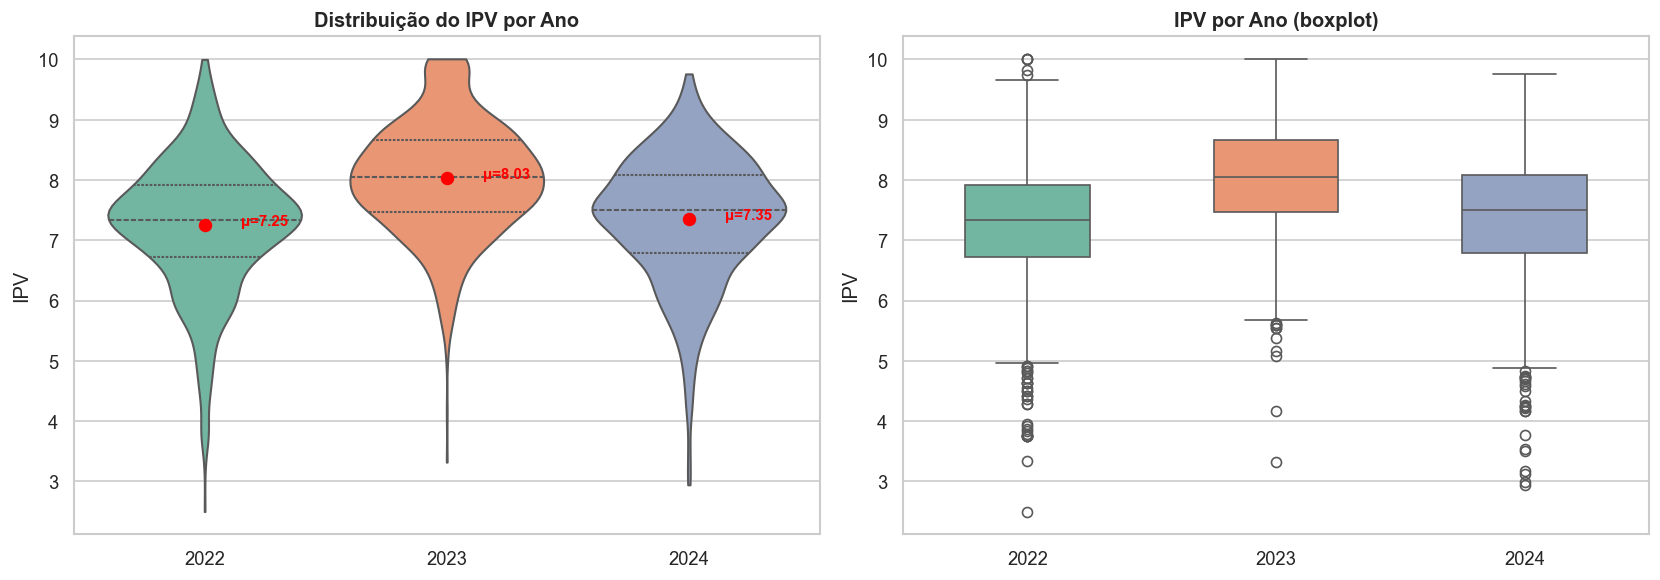

=== IPV — Estatísticas por ano ===
       count  mean   std   min   25%   50%   75%    max
ano                                                    
2022   860.0  7.25  1.09  2.50  6.72  7.33  7.92  10.00
2023   938.0  8.03  0.95  3.32  7.46  8.04  8.67  10.01
2024  1054.0  7.35  1.05  2.94  6.79  7.50  8.09   9.76


In [2]:
# Distribuição do IPV por ano
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dados_violin = df[df['IPV'].notna()].copy()
dados_violin['ano'] = dados_violin['ano'].astype(str)

sns.violinplot(data=dados_violin, x='ano', y='IPV', ax=axes[0],
               palette='Set2', inner='quartile', cut=0)

medias = dados_violin.groupby('ano')['IPV'].mean()
for i, (ano, media) in enumerate(medias.items()):
    axes[0].scatter(i, media, color='red', s=50, zorder=5)
    axes[0].text(i + 0.15, media, f'μ={media:.2f}', fontsize=9, fontweight='bold', color='red')

axes[0].set_title('Distribuição do IPV por Ano', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('IPV')

sns.boxplot(data=dados_violin, x='ano', y='IPV', ax=axes[1], palette='Set2', width=0.5)
axes[1].set_title('IPV por Ano (boxplot)', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('IPV')

plt.tight_layout()
plt.show()

print('=== IPV — Estatísticas por ano ===')
print(df.groupby('ano')['IPV'].describe().round(2).to_string())

##### 💡 Insights

- IPV subiu em 2023 (mean=8.03) e voltou em 2024 (mean=7.35) — mesmo padrão do IEG e IDA
- Diferente do IPP que subiu e ficou, o IPV retornou ao patamar de 2022 (7.25 → 8.03 → 7.35)
- O IPV tem distribuição comprimida: a maioria dos alunos está entre 6.7 e 8.1 (Q1 a Q3) — pouca variação entre alunos
- Mínimos altos (2.50, 3.32, 2.94) — quase nenhum aluno com IPV próximo de zero

❓ Quais indicadores — acadêmicos (IDA), emocionais (IPS, IAA) ou de engajamento (IEG) — mais se associam com o IPV?

###  Correlação do IPV com todos os indicadores

=== Correlação com IPV (todos os anos) ===
  IDA   × IPV: r=0.557 (n=2851)
  IEG   × IPV: r=0.558 (n=2852)
  IAA   × IPV: r=0.063 (n=2852)
  IPS   × IPV: r=-0.049 (n=2846)
  IPP   × IPV: r=0.487 (n=2852)
  IAN   × IPV: r=0.149 (n=2852)

=== Correlação com IPV por ano ===

  2022:
    IDA   × IPV: r=0.617 (n=860)
    IEG   × IPV: r=0.589 (n=860)
    IAA   × IPV: r=0.256 (n=860)
    IPS   × IPV: r=0.208 (n=860)
    IPP   × IPV: r=0.256 (n=860)
    IAN   × IPV: r=0.111 (n=860)

  2023:
    IDA   × IPV: r=0.544 (n=937)
    IEG   × IPV: r=0.449 (n=938)
    IAA   × IPV: r=0.138 (n=938)
    IPS   × IPV: r=0.078 (n=932)
    IPP   × IPV: r=0.516 (n=938)
    IAN   × IPV: r=0.147 (n=938)

  2024:
    IDA   × IPV: r=0.514 (n=1054)
    IEG   × IPV: r=0.535 (n=1054)
    IAA   × IPV: r=0.148 (n=1054)
    IPS   × IPV: r=0.105 (n=1054)
    IPP   × IPV: r=0.750 (n=1054)
    IAN   × IPV: r=0.185 (n=1054)


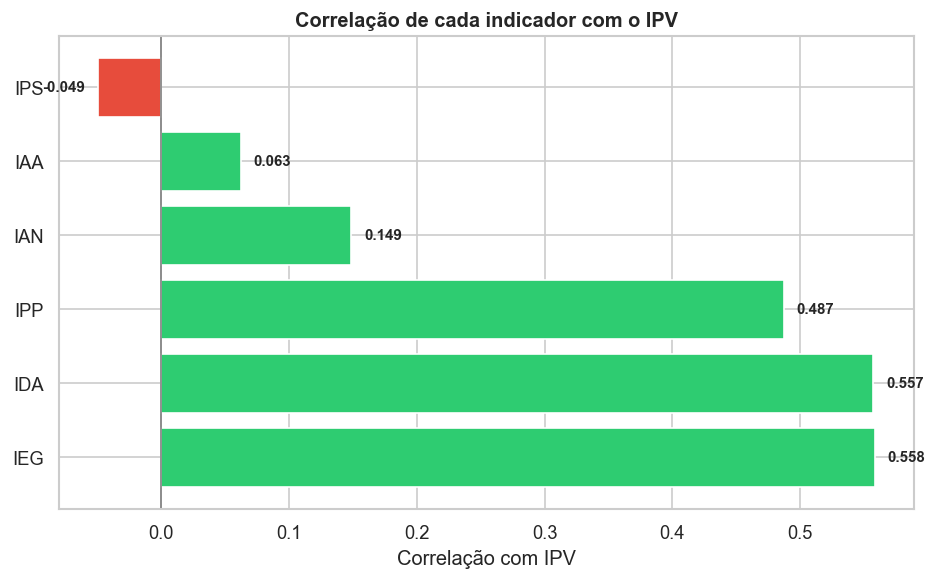

In [3]:
# Quais indicadores mais se correlacionam com o IPV?
df_corr = df[df['IPV'].notna()].copy()
indicadores = ['IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IAN']

# Correlação geral
print('=== Correlação com IPV (todos os anos) ===')
corrs_geral = {}
for ind in indicadores:
    dados = df_corr[['IPV', ind]].dropna()
    corr = dados['IPV'].corr(dados[ind])
    corrs_geral[ind] = corr
    print(f'  {ind:5} × IPV: r={corr:.3f} (n={len(dados)})')

# Correlação por ano
print('\n=== Correlação com IPV por ano ===')
for ano in [2022, 2023, 2024]:
    sub = df_corr[df_corr['ano'] == ano]
    print(f'\n  {ano}:')
    for ind in indicadores:
        dados = sub[['IPV', ind]].dropna()
        if len(dados) > 10:
            corr = dados['IPV'].corr(dados[ind])
            print(f'    {ind:5} × IPV: r={corr:.3f} (n={len(dados)})')

# Visualizar correlações gerais
fig, ax = plt.subplots(figsize=(8, 5))
corrs_sorted = dict(sorted(corrs_geral.items(), key=lambda x: abs(x[1]), reverse=True))
cores = ['#2ecc71' if v > 0 else '#e74c3c' for v in corrs_sorted.values()]

ax.barh(range(len(corrs_sorted)), list(corrs_sorted.values()), color=cores)
ax.set_yticks(range(len(corrs_sorted)))
ax.set_yticklabels(corrs_sorted.keys())
ax.set_xlabel('Correlação com IPV')
ax.set_title('Correlação de cada indicador com o IPV', fontweight='bold')
ax.axvline(0, color='gray', linestyle='-', linewidth=1)

for i, (ind, corr) in enumerate(corrs_sorted.items()):
    ax.text(corr + 0.01 if corr >= 0 else corr - 0.01, i, f'{corr:.3f}',
            va='center', ha='left' if corr >= 0 else 'right', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

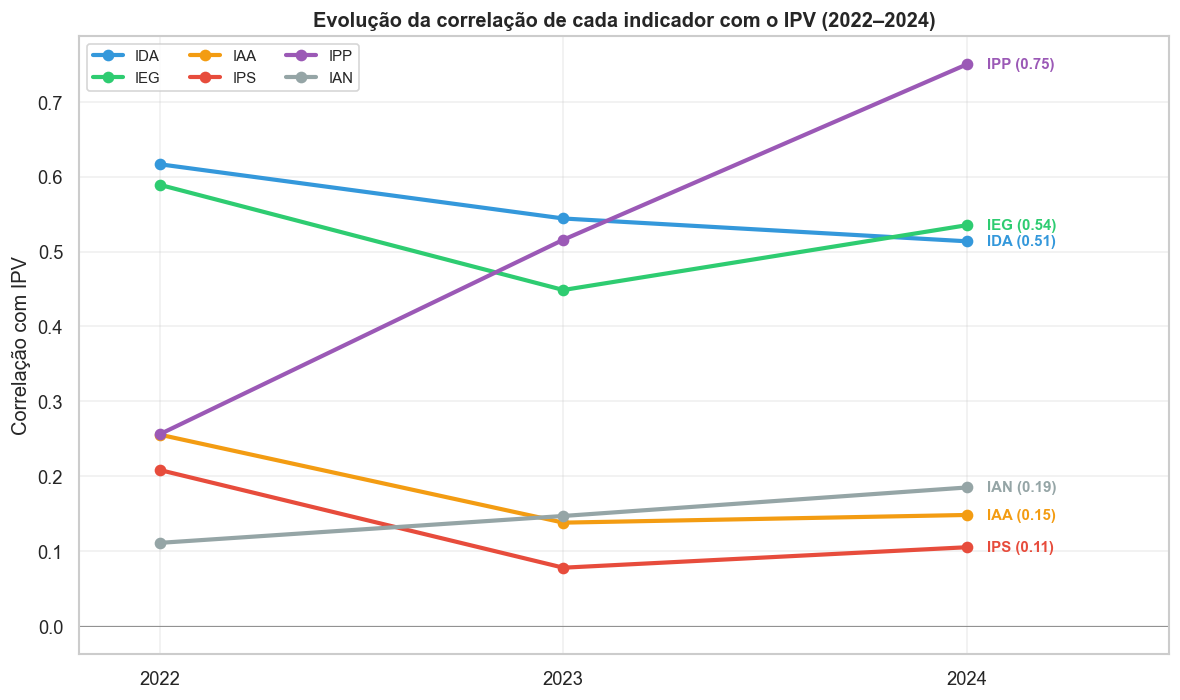

In [7]:
# Evolução da correlação de cada indicador com o IPV ao longo dos anos
corrs_por_ano = {}
for ano in [2022, 2023, 2024]:
    sub = df[df['ano'] == ano]
    corrs_por_ano[ano] = {}
    for ind in indicadores:
        dados = sub[['IPV', ind]].dropna()
        if len(dados) > 10:
            corrs_por_ano[ano][ind] = dados['IPV'].corr(dados[ind])

df_corrs = pd.DataFrame(corrs_por_ano).T

fig, ax = plt.subplots(figsize=(10, 6))

cores_ind = {'IEG': '#2ecc71', 'IDA': '#3498db', 'IPP': '#9b59b6',
             'IAA': '#f39c12', 'IPS': '#e74c3c', 'IAN': '#95a5a6'}

for ind in df_corrs.columns:
    ax.plot(df_corrs.index, df_corrs[ind], marker='o', linewidth=2.5,
            label=f'{ind}', color=cores_ind.get(ind, '#333'))
    # Rótulo no último ponto
    ax.text(2024.05, df_corrs[ind].iloc[-1], f'{ind} ({df_corrs[ind].iloc[-1]:.2f})',
            fontsize=9, fontweight='bold', va='center', color=cores_ind.get(ind, '#333'))

ax.set_xticks([2022, 2023, 2024])
ax.set_xlabel('')
ax.set_ylabel('Correlação com IPV')
ax.set_title('Evolução da correlação de cada indicador com o IPV (2022–2024)', fontweight='bold')
ax.set_xlim(2021.8, 2024.5)
ax.axhline(0, color='gray', linestyle='-', linewidth=0.5)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', ncol=3, fontsize=9)

plt.tight_layout()
plt.show()

##### 💡 Insights

- Em 2022, **IDA (0.62) e IEG (0.59)** eram os indicadores mais associados ao ponto de virada
- Em 2023, IPP cruza com IDA e IEG — os três convergem em ~0.52
- Em 2024, **IPP (0.75) dispara** e se torna o indicador mais forte, enquanto IDA (0.51) e IEG (0.54) estabilizam
- IAA, IPS e IAN permanecem fracos nos 3 anos (todos < 0.25) — aspectos emocionais e de defasagem não influenciam o ponto de virada
- A convergência IPP × IPV pode indicar que os critérios de avaliação de ambos estão se alinhando, ou que a dimensão psicopedagógica se tornou de fato o fator central do ponto de virada

❓ Visualmente, como se comportam os 3 indicadores mais correlacionados (IEG, IDA, IPP) em relação ao IPV?

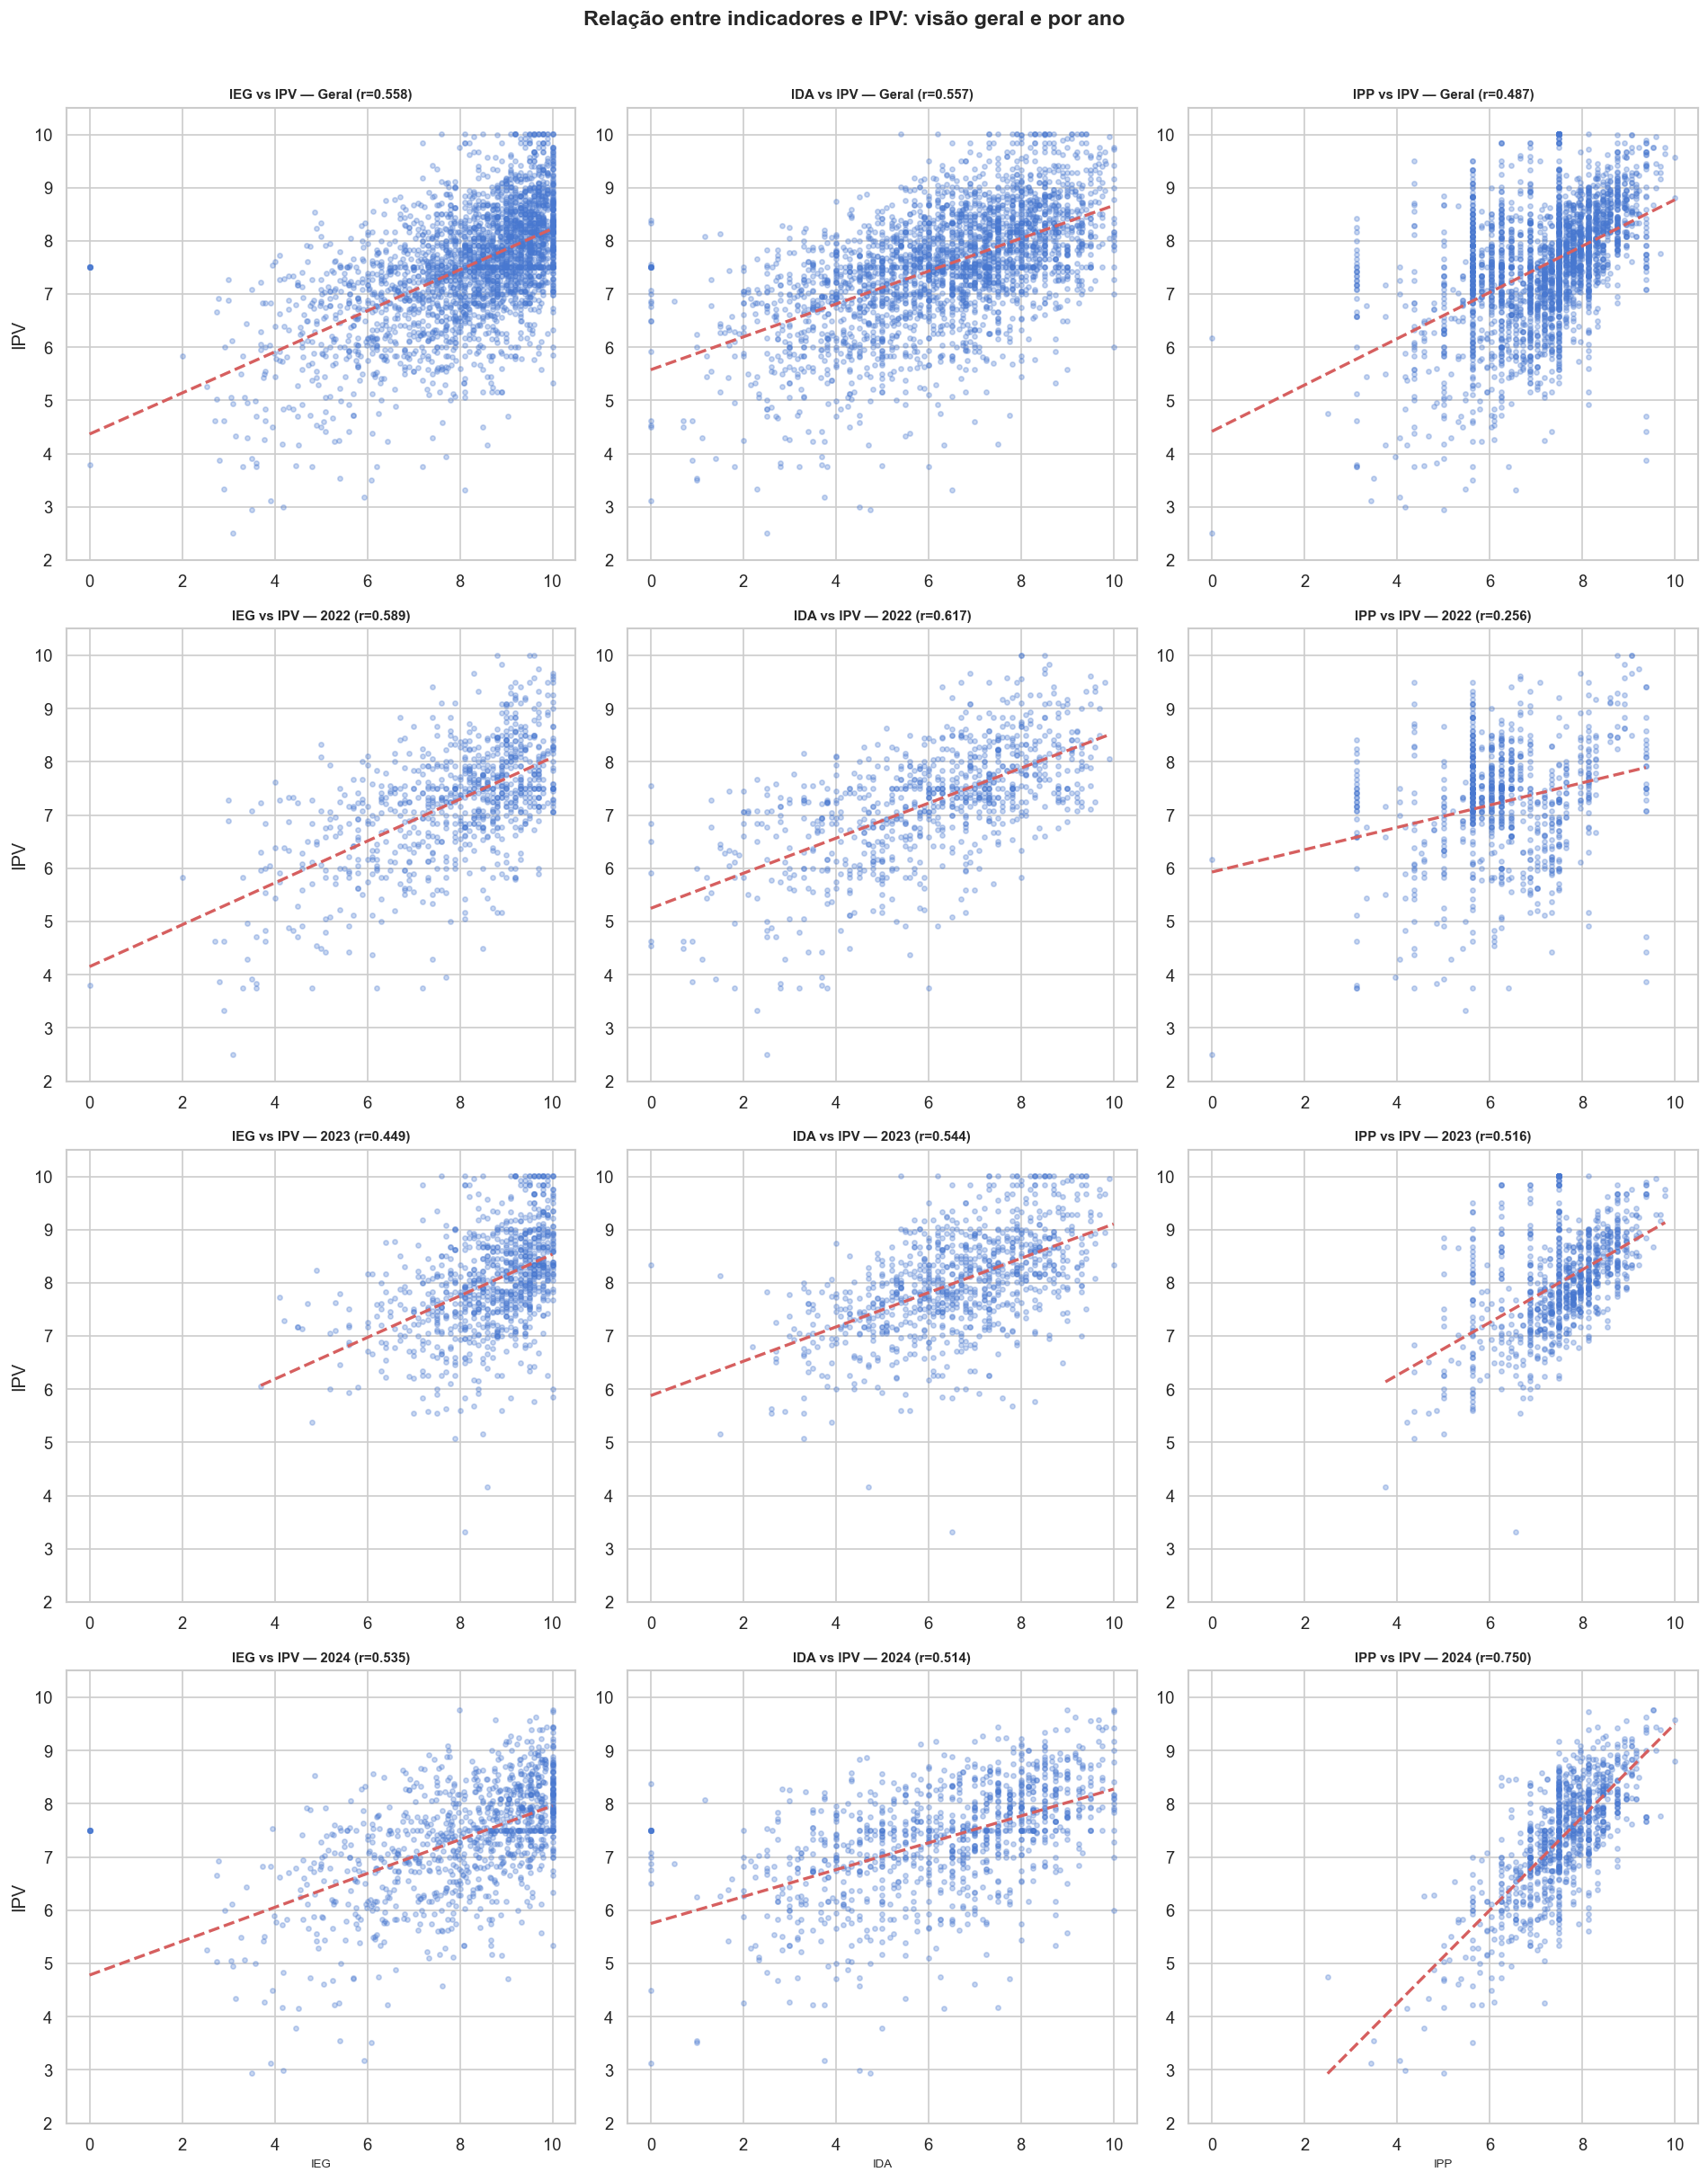

In [8]:
# Scatter dos top 3 indicadores vs IPV — geral + por ano
top3 = list(corrs_sorted.keys())[:3]

fig, axes = plt.subplots(4, 3, figsize=(16, 20))

# Linha 1: todos os anos (geral)
for i, ind in enumerate(top3):
    ax = axes[0][i]
    dados = df_corr[['IPV', ind]].dropna()
    ax.scatter(dados[ind], dados['IPV'], alpha=0.3, s=10)
    
    corr = dados[ind].corr(dados['IPV'])
    z = np.polyfit(dados[ind], dados['IPV'], 1)
    p = np.poly1d(z)
    x_range = np.linspace(dados[ind].min(), dados[ind].max(), 100)
    ax.plot(x_range, p(x_range), 'r--', linewidth=2)
    
    ax.set_title(f'{ind} vs IPV — Geral (r={corr:.3f})', fontweight='bold', fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel('IPV' if i == 0 else '')
    ax.set_xlim(-0.5, 10.5)
    ax.set_ylim(2, 10.5)

# Linhas 2-4: por ano
for row, ano in enumerate([2022, 2023, 2024]):
    sub = df_corr[df_corr['ano'] == ano]
    
    for col, ind in enumerate(top3):
        ax = axes[row + 1][col]
        dados = sub[['IPV', ind]].dropna()
        ax.scatter(dados[ind], dados['IPV'], alpha=0.3, s=10)
        
        corr = dados[ind].corr(dados['IPV'])
        z = np.polyfit(dados[ind], dados['IPV'], 1)
        p = np.poly1d(z)
        x_range = np.linspace(dados[ind].min(), dados[ind].max(), 100)
        ax.plot(x_range, p(x_range), 'r--', linewidth=2)
        
        ax.set_title(f'{ind} vs IPV — {ano} (r={corr:.3f})', fontweight='bold', fontsize=9)
        ax.set_xlabel(ind if row == 2 else '', fontsize=8)
        ax.set_ylabel('IPV' if col == 0 else '')
        ax.set_xlim(-0.5, 10.5)
        ax.set_ylim(2, 10.5)

plt.suptitle('Relação entre indicadores e IPV: visão geral e por ano', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

##### 💡 Insights

- **IEG e IDA** mantêm relação estável com o IPV ao longo dos anos — os scatters mudam pouco de 2022 para 2024
- **IPP** é onde a transformação é dramática e visível:
  - 2022: pontos espalhados sem padrão (r=0.256)
  - 2023: pontos começam a se organizar (r=0.516)
  - 2024: relação linear clara e forte (r=0.750) — a inclinação mais acentuada de todos os gráficos!
- Essa convergência progressiva do IPP com o IPV pode indicar que os critérios de avaliação de ambos foram se alinhando ao longo dos anos, ou que a dimensão psicopedagógica se tornou de fato mais central no processo de ponto de virada

### Evolução temporal: indicadores no tempo atual predizem IPV no futuro?

Pares criados: 1265

=== Indicador atual → IPV no ano seguinte ===
  IDA   (t) → IPV (t+1): r=0.358 (n=1265)
  IEG   (t) → IPV (t+1): r=0.261 (n=1265)
  IAA   (t) → IPV (t+1): r=0.210 (n=1265)
  IPS   (t) → IPV (t+1): r=0.227 (n=1262)
  IPP   (t) → IPV (t+1): r=0.072 (n=1265)
  IAN   (t) → IPV (t+1): r=0.210 (n=1265)


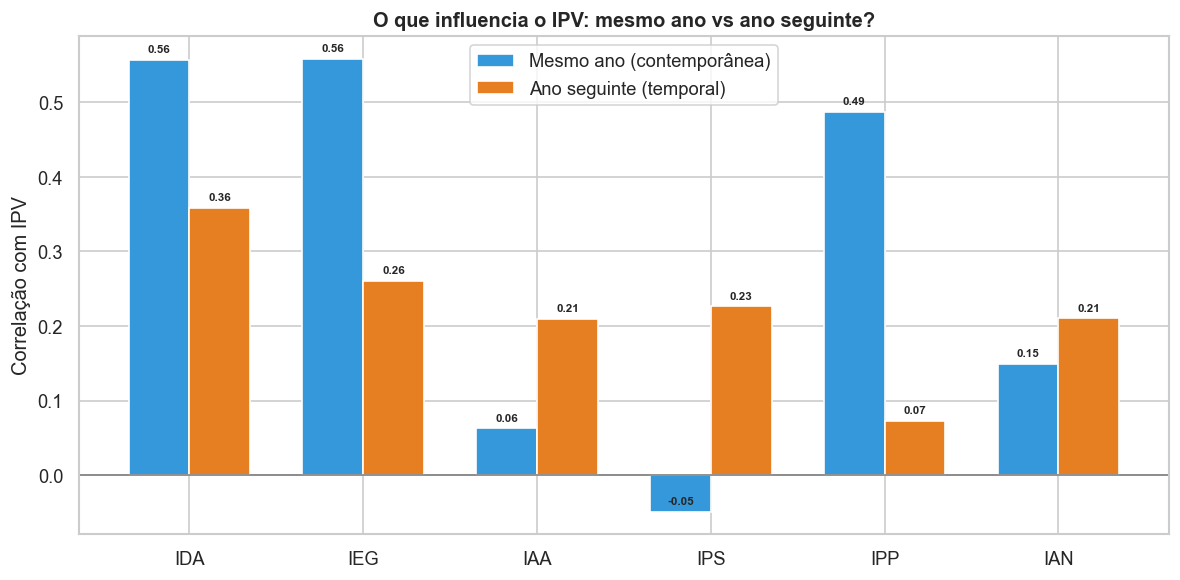

In [5]:
# Análise temporal: quais indicadores em um ano predizem o IPV no ano seguinte?
df_temp = df[df['IPV'].notna()].copy()

pares = []
for ra, grupo in df_temp.groupby('RA'):
    grupo = grupo.sort_values('ano')
    for i in range(len(grupo) - 1):
        atual = grupo.iloc[i]
        proximo = grupo.iloc[i + 1]
        if pd.notna(proximo['IPV']):
            par = {'RA': ra, 'ano_atual': atual['ano'], 'IPV_proximo': proximo['IPV']}
            for ind in indicadores:
                par[f'{ind}_atual'] = atual[ind]
            pares.append(par)

df_pares_ipv = pd.DataFrame(pares)
print(f'Pares criados: {len(df_pares_ipv)}')

# Correlação: indicador atual vs IPV no ano seguinte
print(f'\n=== Indicador atual → IPV no ano seguinte ===')
corrs_temporal = {}
for ind in indicadores:
    col = f'{ind}_atual'
    dados = df_pares_ipv[['IPV_proximo', col]].dropna()
    if len(dados) > 10:
        corr = dados['IPV_proximo'].corr(dados[col])
        corrs_temporal[ind] = corr
        print(f'  {ind:5} (t) → IPV (t+1): r={corr:.3f} (n={len(dados)})')

# Comparar: correlação contemporânea vs temporal
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(indicadores))
width = 0.35

vals_contemp = [corrs_geral.get(ind, 0) for ind in indicadores]
vals_temporal = [corrs_temporal.get(ind, 0) for ind in indicadores]

bars1 = ax.bar(x - width/2, vals_contemp, width, label='Mesmo ano (contemporânea)', color='#3498db')
bars2 = ax.bar(x + width/2, vals_temporal, width, label='Ano seguinte (temporal)', color='#e67e22')

ax.set_xticks(x)
ax.set_xticklabels(indicadores)
ax.set_ylabel('Correlação com IPV')
ax.set_title('O que influencia o IPV: mesmo ano vs ano seguinte?', fontweight='bold')
ax.legend()
ax.axhline(0, color='gray', linestyle='-', linewidth=1)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', fontsize=7, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', fontsize=7, fontweight='bold')

plt.tight_layout()
plt.show()

##### 💡 Insights

- O IPV parece mais explicado pelo contexto do ano corrente do que pelo histórico do ano anterior.
  - As correlações do ano atual são claramente maiores que as temporais para quase todos os indicadores.

- **IDA e IEG são os melhores sinais do IPV no mesmo ano.**
  - Ambos chegam a `r=0.56` na visão contemporânea, reforçando que desempenho acadêmico e engajamento caminham junto com o ponto de virada.

- **O IPP é o caso mais sensível à mudança temporal.**
  - No mesmo ano, a relação com IPV é forte (`r=0.49`), mas no ano seguinte praticamente desaparece (`r=0.07`).
  - Isso sugere um indicador mais reativo ao momento do que um preditor estável.

- **IAA e IPS têm relação fraca no presente, mas ganham leve força no horizonte temporal.**
  - Ainda assim, as correlações seguem baixas (`~0.21` a `0.23`), então o poder explicativo isolado é limitado.

- **IAN permanece como um sinal fraco para IPV nas duas leituras.**
  - Mesmo com leve aumento no temporal, a relação continua modesta, indicando baixa capacidade de antecipar o ponto de virada sozinho.

**Conclusão curta:**
- O IPV parece refletir principalmente o estado atual do aluno, com destaque para `IDA`, `IEG` e `IPP`. Já os indicadores do ano anterior têm menor poder explicativo, o que reforça a ideia de que o ponto de virada é mais um retrato do momento do que uma consequência facilmente antecipável.


Pares válidos criados: 1255

=== Distribuição por transição ===
transicao
2022->2023    574
2023->2024    681

=== 2022->2023 ===
n de pares: 574
  IPV(atual) × IPV(próximo): r=0.479 (n=574)
  IDA   | mesmo ano: r=0.581 (n=574) | ano seguinte: r=0.415 (n=574)
  IEG   | mesmo ano: r=0.544 (n=574) | ano seguinte: r=0.373 (n=574)
  IAA   | mesmo ano: r=0.188 (n=574) | ano seguinte: r=0.155 (n=574)
  IPS   | mesmo ano: r=0.190 (n=574) | ano seguinte: r=0.201 (n=574)
  IPP   | mesmo ano: r=0.233 (n=574) | ano seguinte: r=0.124 (n=574)
  IAN   | mesmo ano: r=0.118 (n=574) | ano seguinte: r=0.178 (n=574)

=== 2023->2024 ===
n de pares: 681
  IPV(atual) × IPV(próximo): r=0.471 (n=681)
  IDA   | mesmo ano: r=0.513 (n=681) | ano seguinte: r=0.421 (n=681)
  IEG   | mesmo ano: r=0.460 (n=681) | ano seguinte: r=0.364 (n=681)
  IAA   | mesmo ano: r=0.114 (n=681) | ano seguinte: r=0.149 (n=681)
  IPS   | mesmo ano: r=0.037 (n=678) | ano seguinte: r=0.082 (n=678)
  IPP   | mesmo ano: r=0.502 (n=681) |

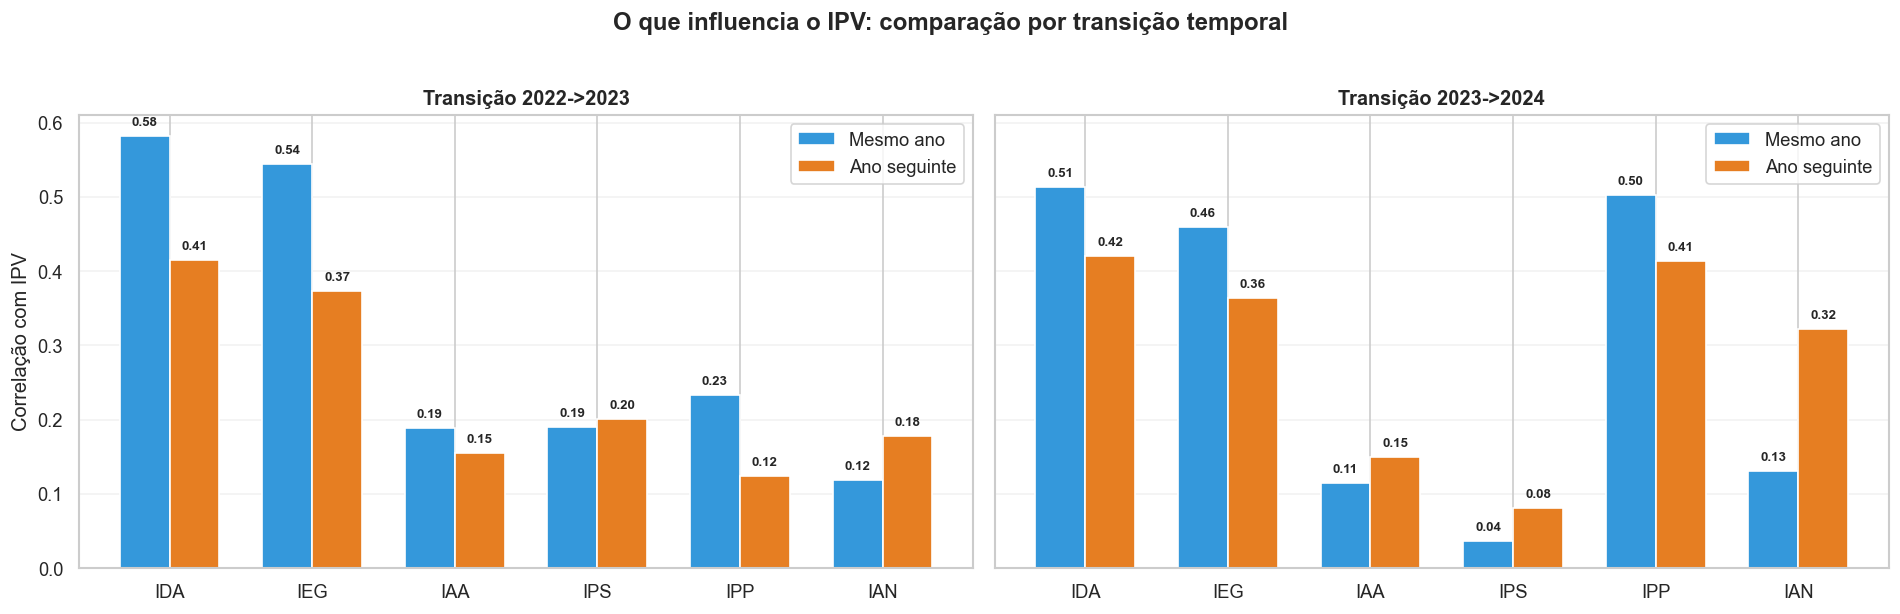


=== Resumo consolidado ===
 transicao indicador  contemporanea  temporal  n_cont  n_temp
2022->2023       IAA          0.188     0.155     574     574
2022->2023       IAN          0.118     0.178     574     574
2022->2023       IDA          0.581     0.415     574     574
2022->2023       IEG          0.544     0.373     574     574
2022->2023       IPP          0.233     0.124     574     574
2022->2023       IPS          0.190     0.201     574     574
2023->2024       IAA          0.114     0.149     681     681
2023->2024       IAN          0.131     0.322     681     681
2023->2024       IDA          0.513     0.421     681     681
2023->2024       IEG          0.460     0.364     681     681
2023->2024       IPP          0.502     0.414     681     681
2023->2024       IPS          0.037     0.082     678     678


In [20]:
# Análise temporal quebrada por transição: 2022->2023 e 2023->2024

transicoes = [(2022, 2023), (2023, 2024)]
pares = []

for ra, grupo in df[df['IPV'].notna()].groupby('RA'):
    grupo = grupo.sort_values('ano').reset_index(drop=True)

    for i in range(len(grupo) - 1):
        atual = grupo.iloc[i]
        proximo = grupo.iloc[i + 1]

        if (atual['ano'], proximo['ano']) not in transicoes:
            continue

        registro = {
            'RA': ra,
            'transicao': f"{int(atual['ano'])}->{int(proximo['ano'])}",
            'IPV_atual': atual['IPV'],
            'IPV_proximo': proximo['IPV']
        }

        for ind in indicadores:
            registro[f'{ind}_atual'] = atual[ind]
            registro[f'{ind}_proximo'] = proximo[ind]

        pares.append(registro)

df_pares = pd.DataFrame(pares)

print(f'Pares válidos criados: {len(df_pares)}')
print('\n=== Distribuição por transição ===')
print(df_pares['transicao'].value_counts().sort_index().to_string())

# Resumo das correlações por transição
resumo = []

for transicao in ['2022->2023', '2023->2024']:
    sub = df_pares[df_pares['transicao'] == transicao].copy()

    print(f'\n=== {transicao} ===')
    print(f'n de pares: {len(sub)}')

    if len(sub) == 0:
        continue

    # Estabilidade do IPV entre os anos
    dados_ipv = sub[['IPV_atual', 'IPV_proximo']].dropna()
    if len(dados_ipv) > 10:
        corr_ipv = dados_ipv['IPV_atual'].corr(dados_ipv['IPV_proximo'])
        print(f'  IPV(atual) × IPV(próximo): r={corr_ipv:.3f} (n={len(dados_ipv)})')

    for ind in indicadores:
        col_atual = f'{ind}_atual'
        col_proximo = f'{ind}_proximo'

        dados_cont = sub[[col_atual, 'IPV_atual']].dropna()
        dados_temp = sub[[col_atual, 'IPV_proximo']].dropna()

        corr_cont = dados_cont[col_atual].corr(dados_cont['IPV_atual']) if len(dados_cont) > 10 else np.nan
        corr_temp = dados_temp[col_atual].corr(dados_temp['IPV_proximo']) if len(dados_temp) > 10 else np.nan

        resumo.append({
            'transicao': transicao,
            'indicador': ind,
            'contemporanea': corr_cont,
            'temporal': corr_temp,
            'n_cont': len(dados_cont),
            'n_temp': len(dados_temp)
        })

        print(f'  {ind:5} | mesmo ano: r={corr_cont:.3f} (n={len(dados_cont)}) | ano seguinte: r={corr_temp:.3f} (n={len(dados_temp)})')

df_resumo = pd.DataFrame(resumo)

# Plot comparativo por transição
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

cores = {
    'contemporanea': '#3498db',
    'temporal': '#e67e22'
}

for ax, transicao in zip(axes, ['2022->2023', '2023->2024']):
    sub = df_resumo[df_resumo['transicao'] == transicao].copy()

    x = np.arange(len(indicadores))
    width = 0.35

    vals_cont = sub.set_index('indicador').loc[indicadores, 'contemporanea'].tolist()
    vals_temp = sub.set_index('indicador').loc[indicadores, 'temporal'].tolist()

    bars1 = ax.bar(x - width/2, vals_cont, width, label='Mesmo ano', color=cores['contemporanea'])
    bars2 = ax.bar(x + width/2, vals_temp, width, label='Ano seguinte', color=cores['temporal'])

    ax.set_title(f'Transição {transicao}', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(indicadores)
    ax.axhline(0, color='gray', linewidth=1)
    ax.grid(axis='y', alpha=0.25)
    ax.legend()

    for bar in bars1:
        altura = bar.get_height()
        if pd.notna(altura):
            ax.text(
                bar.get_x() + bar.get_width()/2,
                altura + (0.01 if altura >= 0 else -0.03),
                f'{altura:.2f}',
                ha='center',
                va='bottom' if altura >= 0 else 'top',
                fontsize=8,
                fontweight='bold'
            )

    for bar in bars2:
        altura = bar.get_height()
        if pd.notna(altura):
            ax.text(
                bar.get_x() + bar.get_width()/2,
                altura + (0.01 if altura >= 0 else -0.03),
                f'{altura:.2f}',
                ha='center',
                va='bottom' if altura >= 0 else 'top',
                fontsize=8,
                fontweight='bold'
            )

axes[0].set_ylabel('Correlação com IPV')
plt.suptitle('O que influencia o IPV: comparação por transição temporal', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Tabela final para conferência
print('\n=== Resumo consolidado ===')
print(df_resumo.round(3).sort_values(['transicao', 'indicador']).to_string(index=False))


##### 💡 Insights

**Preditores consistentes entre as duas transições:**
- **IDA** é o melhor preditor temporal em ambas (r≈0.42) — desempenho acadêmico de hoje é o que mais prediz o ponto de virada de amanhã
- **IEG** é o segundo (r≈0.37) — engajamento também se mantém preditivo
- **O próprio IPV** prediz a si mesmo (r≈0.47) — quem tem IPV alto tende a manter

**IPP muda entre transições:**
- 2022→2023: temporal r=0.124 (fraco)
- 2023→2024: temporal r=0.414 (forte — segundo melhor)
- A mudança reflete a possível mudança metodológica do IPP, identificada na análise `06_AED_IPV.ipynb`

**IAA e IPS:**
- sempre fracos no poder temporal (<0.20)
- aspectos emocionais não predizem o ponto de virada do ano seguinte de forma relevante

**Todos os indicadores perdem poder na transição do ano atual para o próximo** 
  — IDA cai de ~0.55 para ~0.42
  - IEG cai de ~0.50 para ~0.37.
  - Isso é esperado: prever o futuro é sempre mais difícil que explicar o presente

### ⭐️ Insight Final

#### Quais comportamentos — acadêmicos, emocionais ou de engajamento — mais influenciam o IPV ao longo do tempo?

**Comportamentos acadêmicos (IDA) e de engajamento (IEG) são os que mais influenciam o ponto de virada.**

**No mesmo ano — os 3 principais fatores:**
- IEG (r=0.558) e IDA (r=0.557) — engajamento e desempenho acadêmico, praticamente empatados
- IPP (r=0.487) — avaliação psicopedagógica em terceiro
- IAA (r=0.063), IPS (r=-0.049) e IAN (r=0.149) — aspectos emocionais e defasagem têm influência muito fraca

**Na predição do ano seguinte — IDA lidera:**
- IDA é o melhor preditor temporal em ambas as transições (r≈0.42)
  - o desempenho acadêmico de hoje é o que mais prediz o ponto de virada de amanhã
- IEG é o segundo (r≈0.37)
  - engajamento também se mantém preditivo
- O próprio IPV prediz a si mesmo (r≈0.47)
  - quem tem IPV alto tende a manter
- IAA e IPS continuam fracos (<0.20)
  - aspectos emocionais não predizem o ponto de virada futuro

**A dinâmica muda ao longo dos anos:**
- Em 2022, IDA (r=0.617) e IEG (r=0.589) dominavam — IPP era fraco (r=0.256)
- Em 2024, IPP disparou para r=0.750 e se tornou o indicador mais forte — IDA e IEG se mantiveram estáveis (~0.51–0.54)
  - Essa aumento da associação do IPP com o IPV é o dado mais interessante da análise
  - Pode indicar alinhamento nos critérios de avaliação, que mudou ao longo dos anos, ou que a dimensão psicopedagógica se tornou mais central no processo de ponto de virada

**O IPV reflete mais o momento atual do que o passado:**
- Todos os indicadores perdem poder quando usados para prever o IPV do ano seguinte vs explicar o do ano corrente
- O IPP é o caso mais extremo: r=0.487 no mesmo ano -> r=0.072 no ano seguinte
  - indicador reativo ao momento, não preditor estável

**⚠️ Para o modelo de ML:**
- IDA e IEG são as features mais robustas para prever o IPV
  - consistentes entre anos e entre análise contemporânea e temporal
- IPP é útil como feature contemporânea mas não como preditora entre anos
- Considerar o IPV do ano anterior como feature (r≈0.47 de autocorrelação)